# `q.plot` tutorial

A hands-on introduction to QRT's Matplotlib helpers for quantitative-research return streams.

The notebook downloads and caches daily AAPL and SPY data through QRT's Yahoo Finance vendor. AAPL is the example strategy and SPY is the benchmark.

## 1. Library API and feature map

**Package:** `qrt` (Quant Research Tools)

From a repository checkout, create the environment with `uv sync`, then open this notebook with that environment selected. The plotting namespace is `q.plot`.

This tutorial covers:

- `col`, `equity`, and `drawdown` for focused charts;
- `plot` and `tearsheet` for an equity-and-drawdown report;
- `performance` and `infer_periods_per_year` for headline metrics;
- rolling volatility, Sharpe, beta, and alpha diagnostics;
- calendar-month aggregation and heatmaps; and
- benchmark-relative performance statistics.

All return-oriented functions accept a pandas `Series` of **periodic returns**, not price levels.

## 2. Download AAPL and SPY with QRT

QRT's Yahoo Finance vendor downloads OHLCV data and caches it locally, so repeating this notebook does not re-download the same date range. A daily `DatetimeIndex` lets QRT infer the conventional 252 trading periods per year.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import qrt as q

vendor = q.vendors.get_vendor("yfinance")
ohlc = vendor.fetch_ohlc_many(
    ["AAPL", "SPY"],
    start_date="2020-01-01",
    end_date="2025-01-01",
    time_interval="1D",
)

aapl = ohlc["AAPL"]
spy = ohlc["SPY"]
strategy = aapl["close"].pct_change().rename("AAPL")
benchmark = spy["close"].pct_change().rename("SPY")
returns = pd.concat([strategy, benchmark], axis=1).dropna()
strategy = returns["AAPL"]
benchmark = returns["SPY"]

returns.head()

Fetching OHLC (yfinance): 100%|██████████| 2/2 [00:00<00:00, 396.04it/s]


,AAPL,SPY
datetime,,
2020-01-03,-0.009722,-0.007572
2020-01-06,0.007968,0.003815
2020-01-07,-0.004703,-0.002812
2020-01-08,0.016086,0.005330
2020-01-09,0.021241,0.006780


## 3. Returns: simple versus log

Most workflows begin with prices and transform them into simple returns using `pct_change()`. QRT treats simple returns as the default. If the input is log returns, pass `return_type="log"`; QRT converts them before compounding or calculating metrics.

A simple return of $r_t$ compounds as $1+r_t$. In this tutorial, `strategy` is AAPL's daily return stream and `benchmark` is SPY's.

In [2]:
# In a price-based workflow:
# simple_returns = close_prices.pct_change().dropna()
# log_returns = np.log(close_prices).diff().dropna()
# q.plot.performance(log_returns, return_type="log")

print(f"Inferred annualization frequency: {q.plot.infer_periods_per_year(strategy.index)}")
print(f"Simple and converted log returns agree: {np.allclose(np.expm1(np.log1p(strategy)), strategy)}")

Inferred annualization frequency: 252
Simple and converted log returns agree: True


## 4. Start with focused charts

`col()` renders one or more numeric columns, including wildcard-selected columns. `equity()` compounds a return stream into growth of $1; `drawdown()` shows the decline from each running peak.

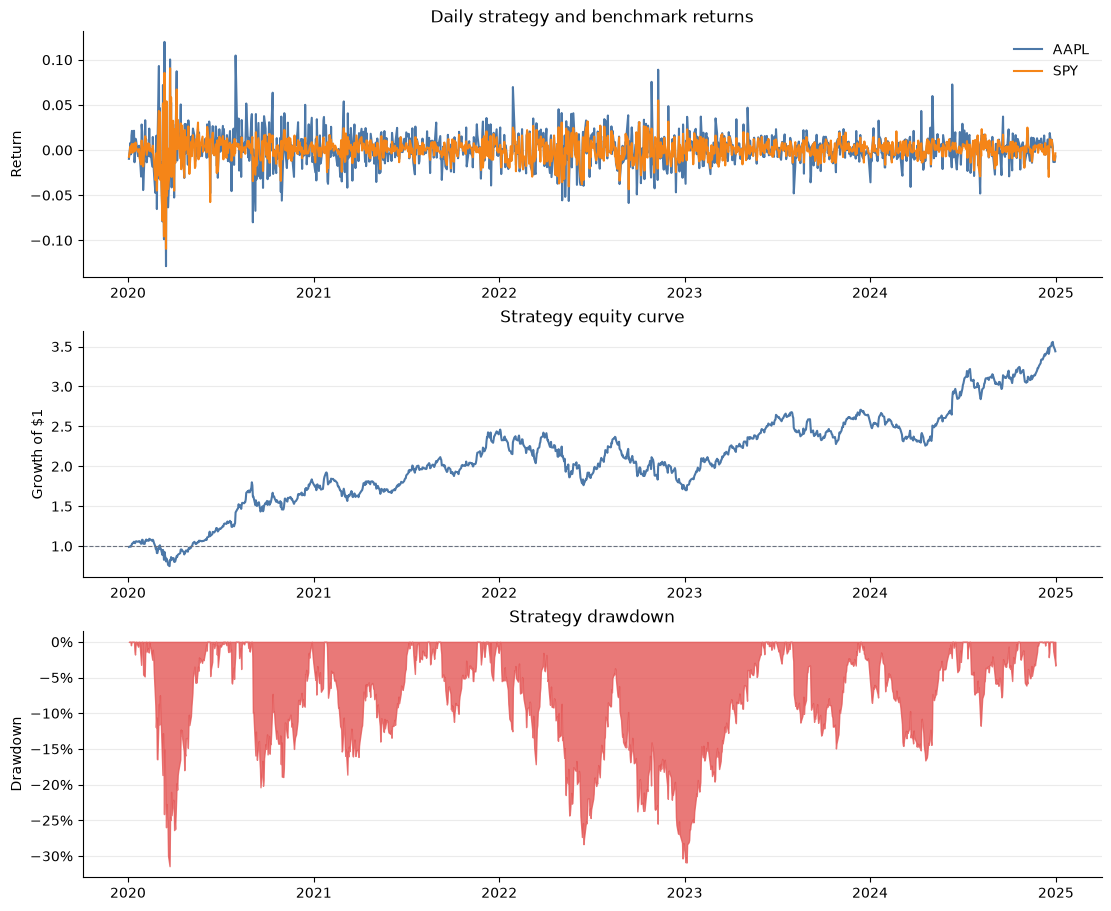

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), layout="constrained")
q.plot.col(returns, ax=axes[0], title="Daily strategy and benchmark returns", ylabel="Return")
q.plot.equity(strategy, ax=axes[1], title="Strategy equity curve")
q.plot.drawdown(strategy, ax=axes[2], title="Strategy drawdown")
plt.show()

## 5. Build a compact performance report

`plot()` combines equity, drawdown, and headline statistics. Supply a benchmark `Series`—not a ticker string—when comparing return streams. `tearsheet()` is an equivalent report-oriented alias.

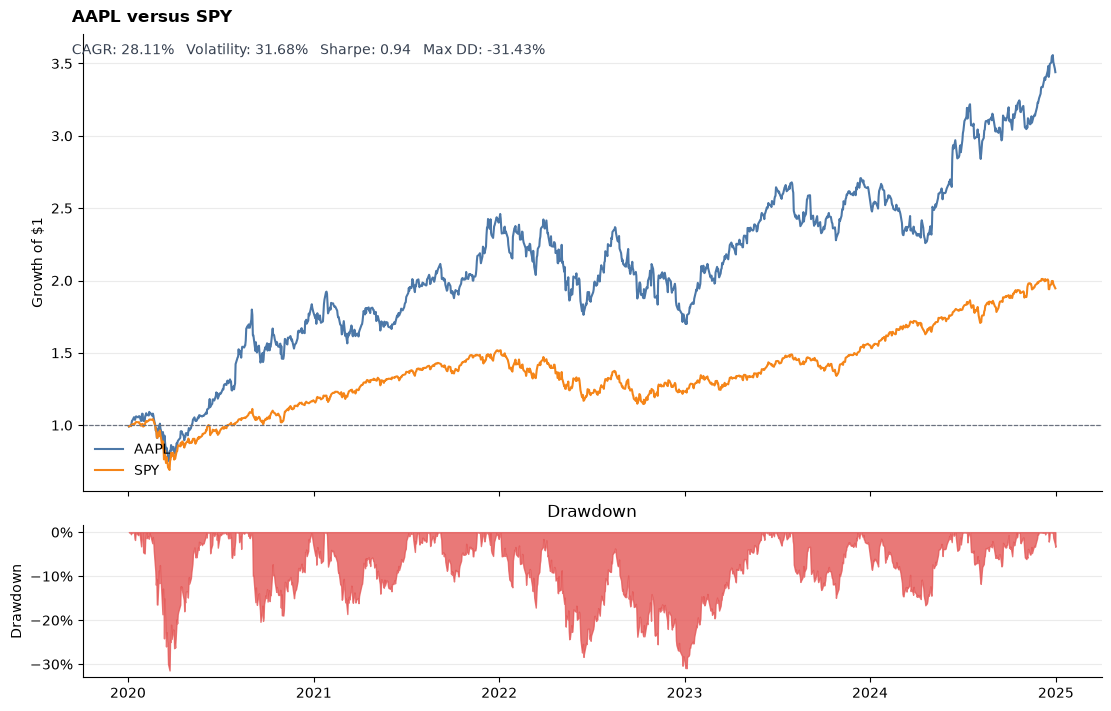

In [4]:
figure, _ = q.plot.plot(
    strategy,
    benchmark=benchmark,
    title="AAPL versus SPY",
)
plt.show()

## 6. Inspect headline performance metrics

`performance()` returns a pandas `Series`, making it easy to select, compare, serialize, or add to a research summary. Pass `periods_per_year` explicitly when the inferred calendar frequency is not appropriate for the strategy.

In [5]:
strategy_metrics = q.plot.performance(strategy)
benchmark_metrics = q.plot.performance(benchmark)

pd.concat([strategy_metrics, benchmark_metrics], axis=1, keys=["Strategy", "Benchmark"])

,Strategy,Benchmark
Total Return,2.440024,0.945850
CAGR,0.281057,0.142773
Volatility,0.316786,0.209973
Sharpe,0.940356,0.741232
Sortino,1.394941,1.035944
Calmar,0.894309,0.423441
Max Drawdown,-0.314273,-0.337173
Win Rate,0.533015,0.547335
Periods,1257.000000,1257.000000


## 7. Diagnose changing risk and benchmark sensitivity

Rolling metrics make regime changes visible. A 63-business-day window is roughly one quarter. Beta measures sensitivity to the benchmark; Jensen alpha measures annualized return unexplained by that beta.

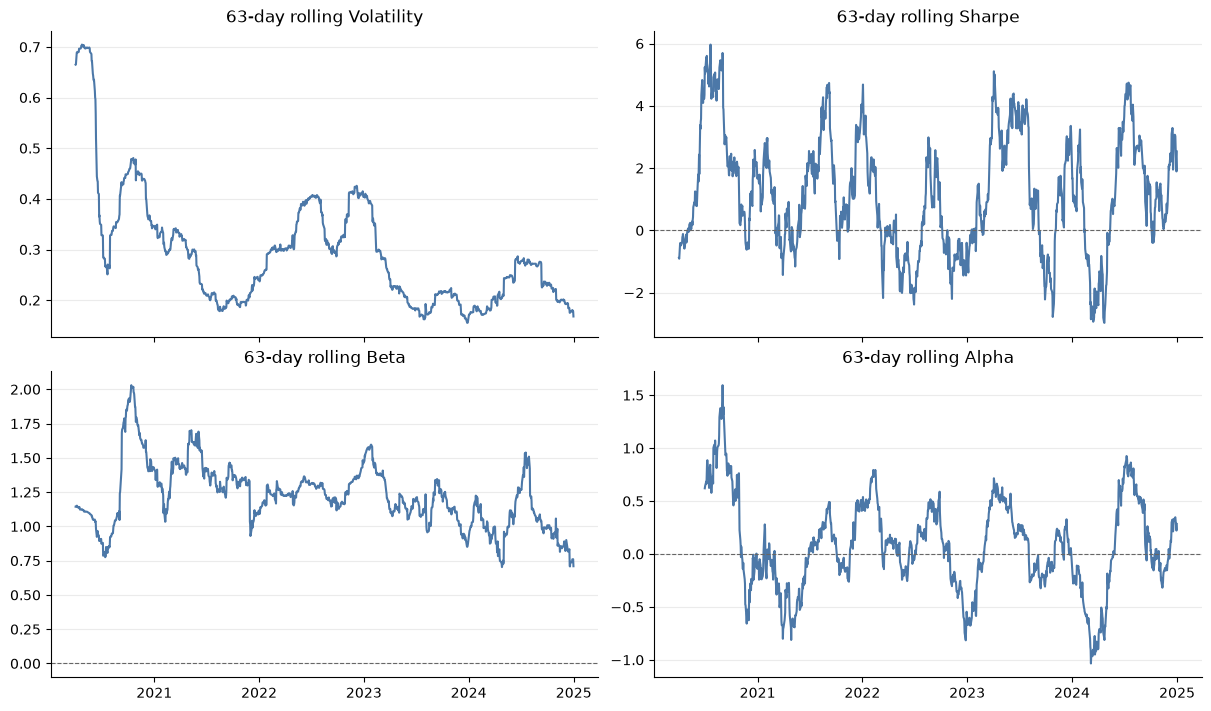

In [6]:
window = 63
rolling = pd.concat(
    {
        "Volatility": q.plot.rolling_volatility(strategy, window),
        "Sharpe": q.plot.rolling_sharpe(strategy, window),
        "Beta": q.plot.rolling_beta(strategy, benchmark, window),
        "Alpha": q.plot.rolling_alpha(strategy, benchmark, window),
    },
    axis=1,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, layout="constrained")
for axis, (name, values) in zip(axes.flat, rolling.items(), strict=True):
    q.plot.col(values, ax=axis, title=f"{window}-day rolling {name}")
    if name in {"Sharpe", "Beta", "Alpha"}:
        axis.axhline(0, color="0.4", linewidth=0.8, linestyle="--")
plt.show()

## 8. Review calendar returns

`monthly_returns()` compounds daily returns within each calendar month. It and `monthly_heatmap()` require a `DatetimeIndex`, which preserves the calendar boundaries used for aggregation.

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2020,3.0%,-11.5%,-7.0%,15.5%,8.5%,14.7%,16.5%,21.7%,-10.3%,-6.0%,9.5%,11.5%
2021,-0.6%,-8.0%,0.7%,7.6%,-5.0%,9.9%,6.5%,4.2%,-6.8%,5.9%,10.5%,7.4%
2022,-1.6%,-5.4%,5.7%,-9.7%,-5.4%,-8.1%,18.9%,-3.1%,-12.1%,11.0%,-3.3%,-12.2%
2023,11.1%,2.3%,11.9%,2.9%,4.6%,9.4%,1.3%,-4.2%,-8.9%,-0.3%,11.4%,1.4%
2024,-4.2%,-1.9%,-5.1%,-0.7%,13.0%,9.6%,5.4%,3.2%,1.7%,-3.0%,5.2%,5.5%


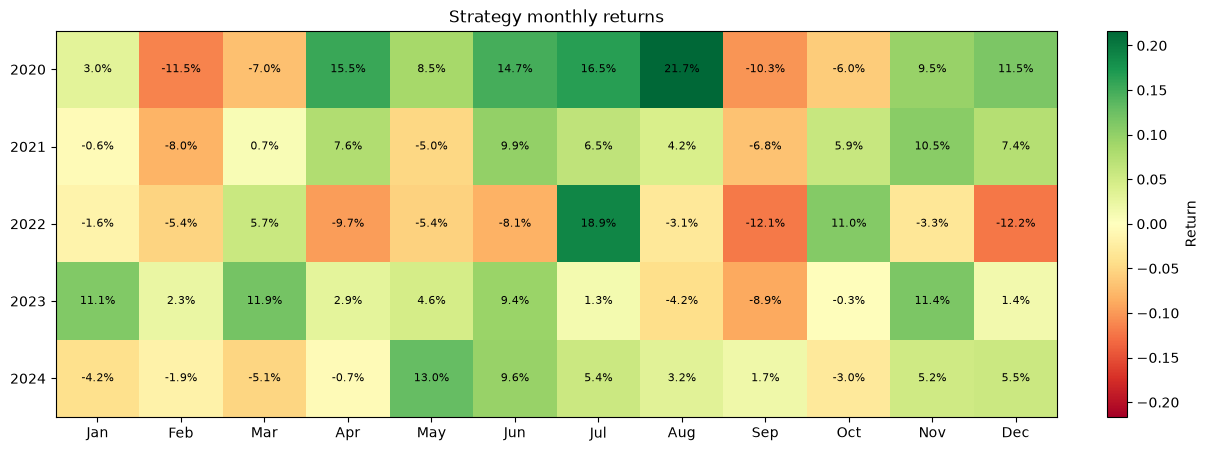

In [7]:
monthly = q.plot.monthly_returns(strategy)
display(monthly.style.format("{:.1%}"))

ax = q.plot.monthly_heatmap(strategy, title="Strategy monthly returns")
plt.show()

## 9. Quantify benchmark-relative results

`benchmark_stats()` first aligns the two series on their shared dates, then calculates active return, beta, alpha, correlation, tracking error, and information ratio. Use these alongside the standalone performance metrics rather than interpreting any single statistic in isolation.

In [8]:
comparison = q.plot.benchmark_stats(strategy, benchmark)
percent_metrics = comparison.index.difference(["Beta", "Correlation", "Information Ratio", "Periods"])
ratio_metrics = ["Beta", "Correlation", "Information Ratio", "Periods"]

comparison.to_frame("AAPL vs SPY").style.format(
    "{:.2%}", subset=pd.IndexSlice[percent_metrics, :]
).format(
    {"AAPL vs SPY": "{:.2f}"}, subset=pd.IndexSlice[ratio_metrics[:-1], :]
).format(
    {"AAPL vs SPY": "{:.0f}"}, subset=pd.IndexSlice[["Periods"], :]
)

,AAPL vs SPY
Strategy Total Return,244.00%
Benchmark Total Return,94.59%
Active Return,76.79%
Beta,1.19
Alpha,11.22%
Correlation,0.79
Tracking Error,19.81%
Information Ratio,0.72
Periods,1257


## 10. Reuse the recipe with your own strategy

1. Download OHLCV with a QRT vendor, then start from an indexed `Series` of periodic returns; use `prices.pct_change().dropna()` when starting from close prices.
2. Keep strategy and benchmark series in the same frequency and timezone.
3. Use `performance()` for tables, rolling helpers for stability checks, and `plot()` or `tearsheet()` for a compact review.
4. Pair the visual report with `monthly_heatmap()` and `benchmark_stats()` before deciding whether a result is robust.

`tearsheet()` is a report-oriented alias for `plot()`: `figure, axes = q.plot.tearsheet(strategy, benchmark=benchmark)`.